In [102]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from matplotlib.pyplot import rc_context
import os
import seaborn as sns
import numpy as np

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm,Normalize

In [103]:
# Path definition
Inputpath = "../data_wildfire/"
Outputpath = "../fig_wildfire/networks"
Resultpath = "../numerical_result_wf/"

#df_node = pd.read_csv(os.path.join(Inputpath,"nodes_0.5hr.csv"), header = 0)
df_arc = pd.read_excel(os.path.join(Inputpath,"arcs_sonoma_15min.xlsx"), header = 0)
df_node = pd.read_excel(os.path.join(Inputpath,"nodes_sonoma_15min.xlsx"), header = 0)
df_char_damFac = pd.read_csv(os.path.join(Inputpath, "charging_cap_damFac.csv"), header = 0)
df_road_damFac = pd.read_csv(os.path.join(Inputpath, "road_cap_damFac.csv"), header = 0)
df_S_nodes = pd.read_excel(os.path.join(Inputpath,"safe_nodes_15min.xlsx"), header = 0)
df_S_nodes = df_S_nodes[df_S_nodes['Safe'] == 1]
res_foldername = "B10T4evenL29"
res_filename = "s_values.csv"
df_charcap_res = pd.read_csv(os.path.join(Resultpath,res_foldername,res_filename),header=0)


In [104]:
# Path definition
#Inputpath = "../data/"
#Outputpath = "../fig/halfEV_2xRoadCap_0801/"
#Resultpath = "../numerical_result/"

# df_arc = pd.read_csv(os.path.join(Inputpath,"arcs_1hr.csv"), header = 0)
# df_node = pd.read_csv(os.path.join(Inputpath,"nodes_1hr.csv"), header = 0)
# df_S_nodes = pd.read_csv(os.path.join(Inputpath,"safe_nodes_1hr.csv"), header = 0)
# df_S_nodes = df_S_nodes[df_S_nodes['Safe'] == 1]

# res_foldername = "B18T24Init0L14"
# res_filename = "s_values.csv"
# df_charcap_res = pd.read_csv(os.path.join(Resultpath,res_foldername,res_filename),header=0)

In [105]:
# basemap

# [llcrnrlon, llcrnrlat, urcrnrlon, urcrnrlat]
coords = [-123.31,37.95,-121.98,38.86,36]

m = Basemap(projection='merc',
            llcrnrlon = coords[0],
            llcrnrlat = coords[1],
            urcrnrlon = coords[2],
            urcrnrlat = coords[3],
            resolution = 'i',
            #lat_ts = 0,
           suppress_ticks=True)
           #epsg=5520)
    
# m.shadedrelief()
#http://server.arcgisonline.com/arcgis/rest/services

#m.arcgisimage(service='ESRI_Imagery_World_2D', xpixels = 1500, dpi = 100, verbose= False)


0.9733806129343682


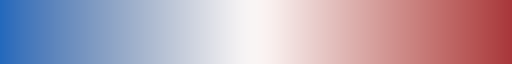

In [106]:
# networkx drawing
G = nx.Graph()
nodes = df_node['Nodes'].tolist()
G.add_nodes_from(nodes)

for i in range(len(df_arc)):
    from_node = df_arc.iloc[i]['From']
    to_node = df_arc.iloc[i]['To']
    G.add_edge(from_node,to_node)
#labels = [str(i) for i in nodes]
node_lats = df_node['Lat'].tolist() # north south
node_lons = df_node['Long'].tolist() # east west
mx,my = m(node_lons,node_lats)
pos = {}
for node in nodes:
    pos[node] = (mx[node-1],my[node-1])

# color nodes in safety and evacuation zones
node_safety_color = []
for node in list(G):
    if node in df_S_nodes['Nodes'].tolist():
        node_safety_color.append('#aac078')
    else:
        node_safety_color.append('#efdba8')


node_capacity_color = df_charcap_res['CharCap'].tolist()
vmin = min(node_capacity_color)
vmax = max(node_capacity_color)
print(vmax)
# node_capacity_color = np.array(df_charcap_res['CharCap'].tolist())
# node_capacity_color = np.log(node_capacity_color+1)
# node_capacity_color = list(node_capacity_color)
cmap = sns.color_palette("vlag", as_cmap=True)
cmap

C:\Users\lucy_\AppData\Local\Temp\ipykernel_17668\631850798.py:40: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, fraction=0.046, pad=0.04, shrink=0.3)


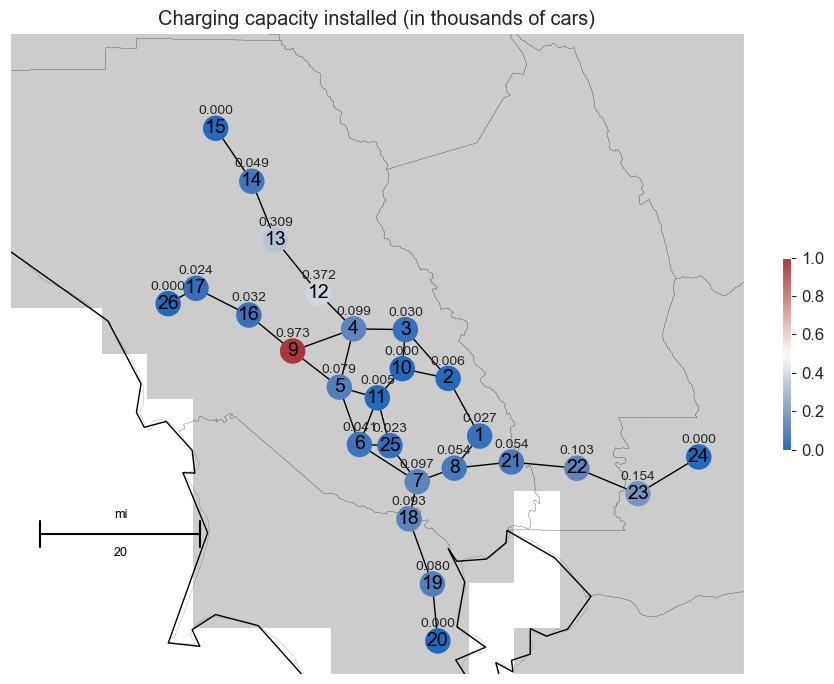

In [107]:
with rc_context({'figure.figsize': (10,7), 'font.size':12}):
    
    # basemap drawing
    m.drawcounties()
    m.drawcoastlines()
    m.drawlsmask(resolution = 'i') #land_color = "#ddaa66", ocean_color="#7777ff",
    
    # draw a map scale
    m.drawmapscale(
        coords[0]+0.2, coords[1]+0.2,
        coords[0], coords[1],
        20.,
        units='mi')
    
    #draw network with node color
    nx.draw_networkx(G,pos,node_size=300,node_color=node_capacity_color,cmap=cmap,
                     with_labels=True, font_size=14
                    )

    norm = Normalize(vmin=0, vmax=1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=LogNorm(vmin=1, vmax=np.exp(3)))
    sm._A = []
    # ax = plt.gca()
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="4%", pad=0.05)
    
    # plot labels
    i = 0
    for x,y in zip(mx,my):
        cap_label = "{:.3f}".format(df_charcap_res['CharCap'][i])
        plt.annotate(cap_label,
                     (x,y),
                     textcoords="offset points",
                     xytext=(0,10),
                     ha='center',
                     fontsize=10)
        i += 1
    
    plt.colorbar(sm, fraction=0.046, pad=0.04, shrink=0.3)
    plt.title('Charging capacity installed (in thousands of cars)')
    # plt.colorbar(shrink=0.3)
    # fig.colorbar(sm, orientation="verticle")
    plt.tight_layout()
    
    plt_filename = res_foldername + "CharCap_map.png"
    outname = os.path.join(Outputpath,plt_filename)
    plt.savefig(outname,dpi=300)
    plt.show()

In [108]:
sm

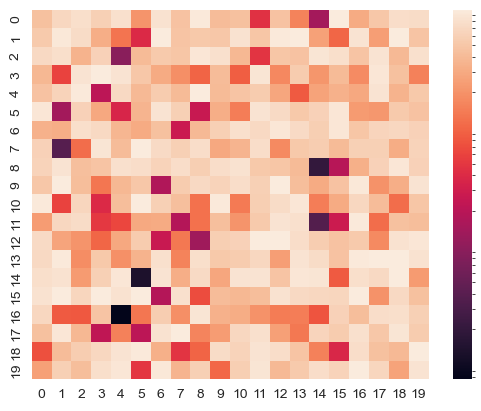

In [109]:
from matplotlib.colors import LogNorm
s=np.random.rand(20,20)
sns.heatmap(s, norm=LogNorm(s.min(),s.max()),
            cbar_kws={"ticks":[0,1,10,1e2,1e3,1e4,1e5]},
            vmin = 0.001, vmax=10000)
plt.show()